## Imports das Bibliotecas

In [1]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Analise dos dados

In [2]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11432 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11432 non-null  int64 
 3   keywords               5072 non-null   object
 4   nome                   11432 non-null  object
 5   sexo                   11432 non-null  object
 6   nascimento             11432 non-null  object
 7   local_nascimento       11432 non-null  object
 8   escolaridade           11170 non-null  object
 9   uris.uriPartido        11432 non-null  object
 10  ementa_principal       11432 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           11432 non-null  object
 15  sigla_partido          1

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [5]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

C:\Users\alexa\AppData\Local\Temp\ipykernel_15256\1803048690.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["

In [6]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_15256\188054785.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (
C:\Users\alexa\AppData\Local\Temp\ipykernel_15256\188054785.py:4: SettingWithCopyWarni

In [7]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3711
1,OUTROS,1581


In [ ]:

## MODELOS SEM VIES

#Outros 100
#Brancos 100

#Gerar um classificar aleátorio / classificador sem viés tem que dar proximo a 50% de acurácia
# E macro F1 fica pior que 50%

#y_true = dados normais
#y_pred = se o valor for maior que 0.7 

#  f1_score(y_true, y_pred, average='macro')



###obs: Aplicar para todos os modelos

In [ ]:
### 2 Experimento

## Remover não divigaveis

## E aumentar as classes de Outros para "INDIGENAS", "PARDOS", "NEGROS"

# Brancos / Pardos / Negros


#Brancos/Total = 0.7
#Pardos/Total = 0.1
#Negros/Total = 0.2



# y_pred_1 = [0,1,2]
# y_pred_2 = [0,1,2]
# y_pred_3 = [0,1,2]

# Se for entre 0 e 7 = BRANCOS
# Entre  0.7 e 0.8 = PARDOS
# Entre  0.8 e 1.0 = NEGROS 


# Fazer uma distribuição uniforme = uma moeda enviesada



# Se for maior que 0.7 é Brancos
# Se for entre 0.7 < x < 0.8 é Pardo
# Se 0.8 > 1.0 é outros



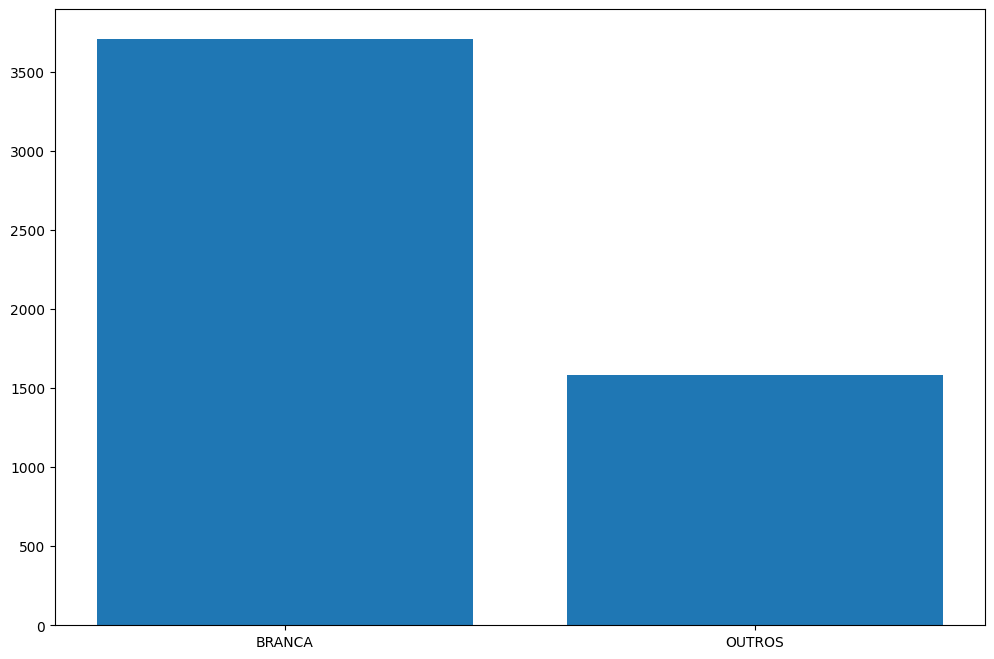

In [8]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [9]:
df["ementa"].dropna().count()

5292

## Bag Of Words

In [10]:
# nltk.download('stopwords')

In [11]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [12]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab

array(['00', '000', '001', ..., 'único', 'útero', 'útil'], dtype=object)

## WORD CLOUD

In [13]:
le = LabelEncoder()

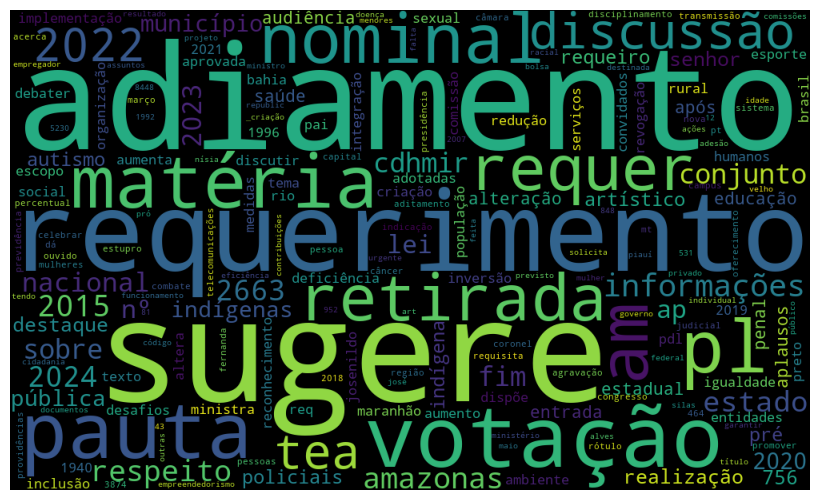

In [14]:
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)
y = le.fit_transform(df["cor"])
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

In [15]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros = df[df["cor"] == "OUTROS"]

tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )

y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])

In [16]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()


In [17]:
X_outros = tf_idf_outros.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf_outros.get_feature_names_out()



## GRUPO 1: PESSOA DE COR DE PELE BRANCA

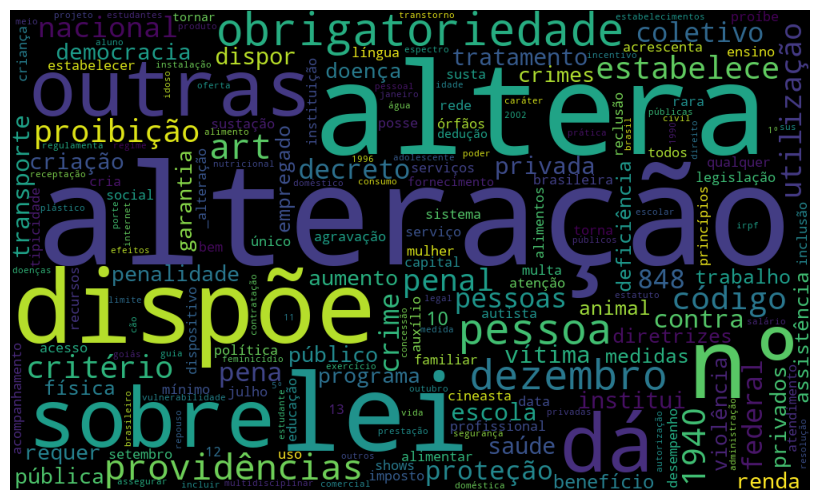

In [18]:
model_brancos = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_brancos, y_brancos)
model_brancos.fit(X_train, y_train)
features_importance = model_brancos.feature_importances_
features_name = tf_idf_brancos.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_brancos = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_brancos) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

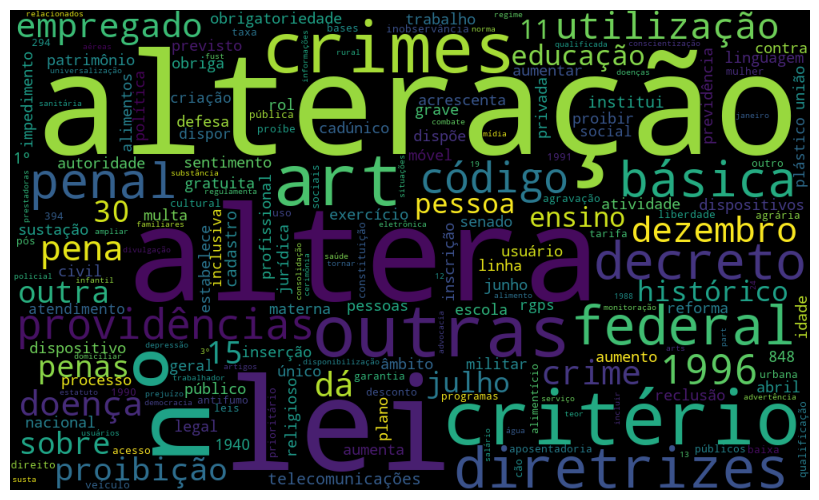

In [19]:
model_outros = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_outros, y_outros)
model_outros.fit(X_train, y_train)
features_importance = model_outros.feature_importances_
features_name = tf_idf_outros.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_outros = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_outros) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## PCA

In [20]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

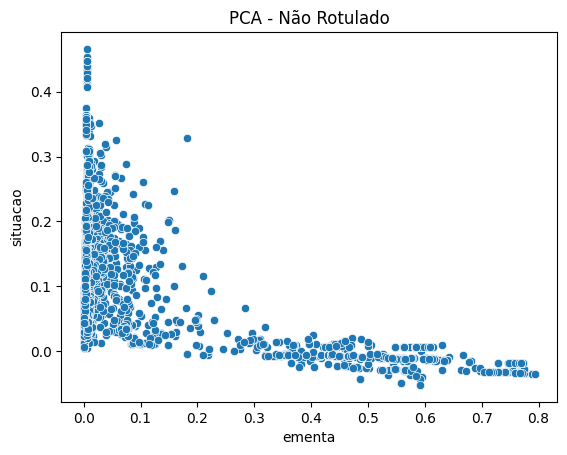

In [21]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

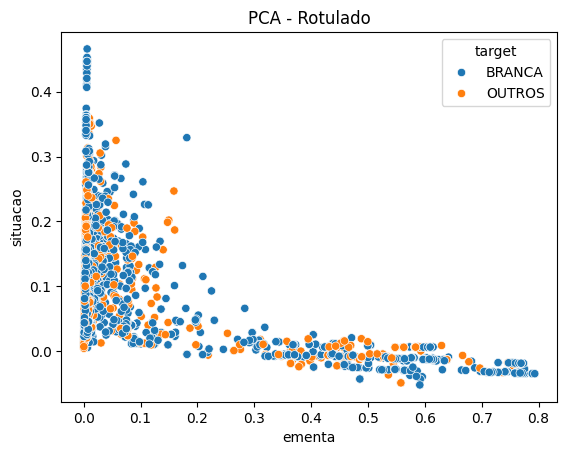

In [22]:
y_map = {0: 'BRANCA', 1: "OUTROS"}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [25]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [26]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42) 

# Logistic Regression

In [27]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.57873167 0.61796537 0.60126779 0.63260827 0.59845457]
Media da Accuracy:  0.7377211443545378
Media da MACRO F1:  0.6058055328076277
Desvio Padrão da MACRO F1:  0.01829683203798745


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.78      0.77       730
           1       0.50      0.48      0.49       329

    accuracy                           0.69      1059
   macro avg       0.63      0.63      0.63      1059
weighted avg       0.68      0.69      0.68      1059



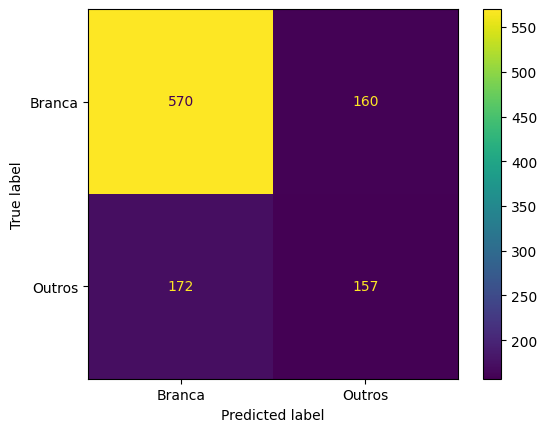

In [28]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [29]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.61837916 0.65823564 0.64732143 0.63438791 0.66364856]
Media da Accuracy:  0.6972820954961613
Media da MACRO F1:  0.6443945408398151
Desvio Padrão da MACRO F1:  0.016418239694799025


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.78      0.77       730
           1       0.49      0.47      0.48       329

    accuracy                           0.68      1059
   macro avg       0.63      0.63      0.63      1059
weighted avg       0.68      0.68      0.68      1059



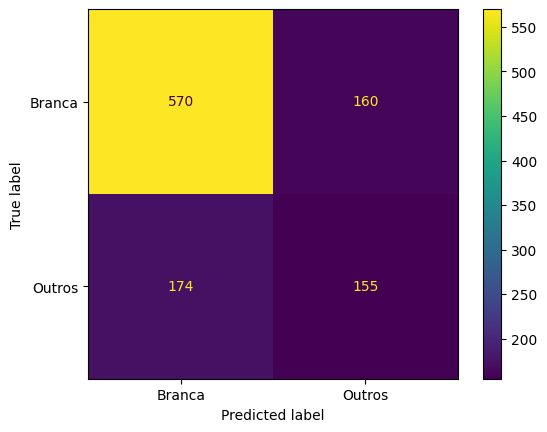

In [30]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [31]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.6006233  0.66693423 0.63867265 0.63896104 0.6205076 ]
Media da Accuracy:  0.7224122696626807
Media da MACRO F1:  0.6331397655762802
Desvio Padrão da MACRO F1:  0.02201571393117753


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.85      0.37      0.52       730
           1       0.38      0.85      0.53       329

    accuracy                           0.52      1059
   macro avg       0.61      0.61      0.52      1059
weighted avg       0.70      0.52      0.52      1059



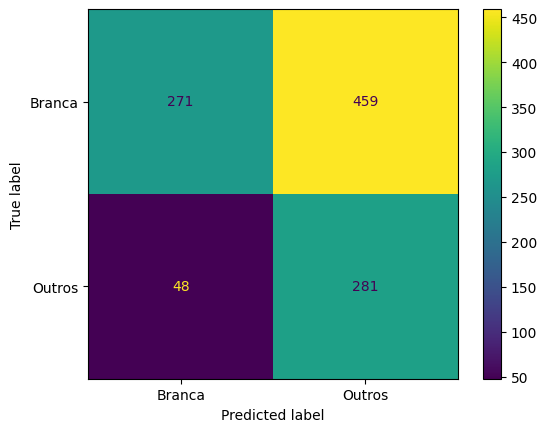

In [32]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [33]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.63790745 0.66062578 0.64256757 0.64182767 0.65318416]
Media da Accuracy:  0.7035149256262373
Media da MACRO F1:  0.6472225269167893
Desvio Padrão da MACRO F1:  0.008399191121820056


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       730
           1       0.50      0.46      0.48       329

    accuracy                           0.69      1059
   macro avg       0.64      0.63      0.63      1059
weighted avg       0.69      0.69      0.69      1059



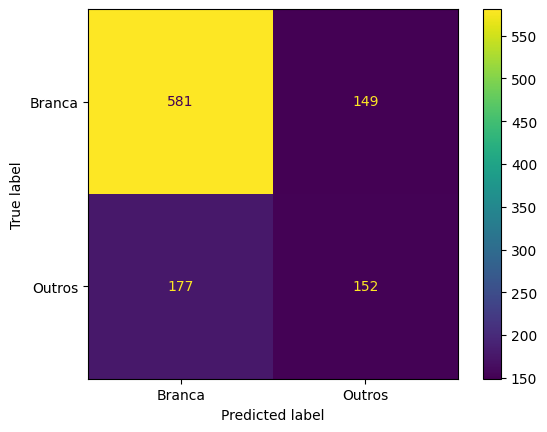

In [34]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [35]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.57324513 0.64151374 0.6190511  0.62850868 0.61222089]
Media da Accuracy:  0.7411211132948121
Media da MACRO F1:  0.6149079084030037
Desvio Padrão da MACRO F1:  0.023034861361654446


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.74      0.91      0.82       730
           1       0.59      0.29      0.38       329

    accuracy                           0.72      1059
   macro avg       0.66      0.60      0.60      1059
weighted avg       0.69      0.72      0.68      1059



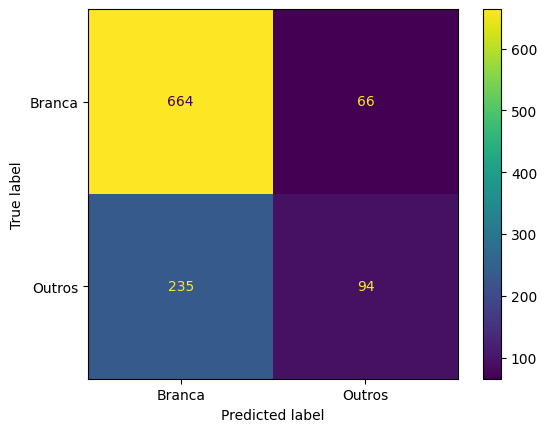

In [36]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [37]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.60490044 0.64841805 0.61857141 0.61278765 0.62987128]
Media da Accuracy:  0.6802718975528863
Media da MACRO F1:  0.622909765609738
Desvio Padrão da MACRO F1:  0.015131090597146218


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       730
           1       0.49      0.42      0.45       329

    accuracy                           0.68      1059
   macro avg       0.62      0.61      0.61      1059
weighted avg       0.67      0.68      0.68      1059



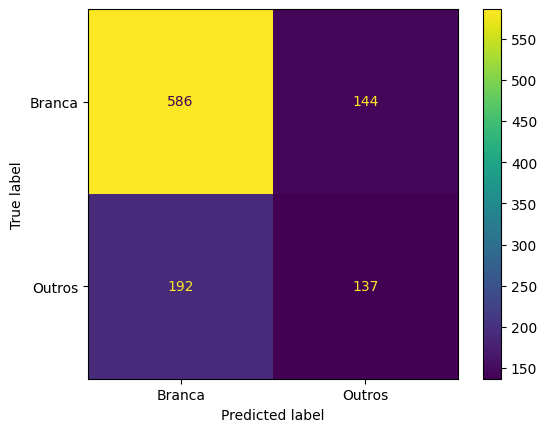

In [38]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [ ]:
#Classificar aleatorio

#30% de Outros 
#70% Brancos

# Se numero aleátorio for maior que 0.2975 Brancos, 
#menor outros

#Outros/Total
#1581/5292

# Resultado
#.29875


